In [ ]:
import os
import json
import re

import pandas as pd
from jiwer import wer, mer, wil, wip, cer

In [ ]:
BASE_DIR = "/lium/corpus/vrac/COVEA"

PATH_REF   = os.path.join(BASE_DIR, "transcriptions_corrigees.json")
PATH_AZURE = os.path.join(BASE_DIR, "transcriptions_azure_speech.json")
PATH_GLADIA = os.path.join(BASE_DIR, "transcriptions_gladia.json")

print("REF   :", PATH_REF)
print("AZURE :", PATH_AZURE)
print("GLADIA:", PATH_GLADIA)

REF   : /lium/corpus/vrac/COVEA/transcriptions_corrigees.json
AZURE : /lium/corpus/vrac/COVEA/transcriptions_azure_speech.json
GLADIA: /lium/corpus/vrac/COVEA/transcriptions_gladia.json


In [ ]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

ref_data   = load_json(PATH_REF)
azure_data = load_json(PATH_AZURE)
gladia_data = load_json(PATH_GLADIA)

print("REFERENCE type:", type(ref_data))
print("AZURE type    :", type(azure_data))
print("GLADIA type   :", type(gladia_data))

print("\nREF keys:", list(ref_data.keys()))
print("\nExample AZURE item:\n", json.dumps(azure_data[0], indent=2)[:800])
print("\nExample GLADIA item:\n", json.dumps(gladia_data[0], indent=2)[:800])

REFERENCE type: <class 'dict'>
AZURE type    : <class 'list'>
GLADIA type   : <class 'list'>

REF keys: ['audio_id', 'annotateur', 'jsonResponse']

Example AZURE item:
 {
  "source": "https://stcovdsecoutia0bexp001.blob.core.windows.net/dev/dev1/bronze/files/benchmark_082025/GMF-P_V2_Indemnisation/101-1747507420.4525072.wav",
  "timestamp": "2025-09-08T14:21:03Z",
  "durationInTicks": 566000000,
  "durationMilliseconds": 56600,
  "duration": "PT56.6S",
  "combinedRecognizedPhrases": [
    {
      "channel": 0,
      "lexical": "bonjour je suis hefi votre assistante virtuelle gmf je vous propose de r\u00e9pondre rapidement \u00e0 cette question pour faire votre d\u00e9claration sinistr\u00e9e et recevoir une r\u00e9f\u00e9rence dossier ensuite un conseiller vous rappellera sous quarante huit heures ouvr\u00e9es je vous invite \u00e0 r\u00e9pondre \u00e0 mes questions comme vous le feriez avec un conseiller pour confirmer votre identit\u00e9 merci de pronon

Example GLADIA item:
 {
  "fi

In [ ]:
# Build reference (gold) transcriptions per audio_id

def build_ref_transcriptions(ref_data):
    """
    Retourne un dict:
        { audio_id (ex: '101-1747507420.4525072') : 'texte de référence complet' }
    à partir de transcriptions_corrigees.json
    """
    audio_id_map = ref_data["audio_id"]      # { "200": "101-..." , ... }
    json_resp    = ref_data["jsonResponse"]  # { "200": { "0": {...}, ...}, ... }

    ref_texts = {}

    for internal_id, audio_name in audio_id_map.items():
        # internal_id est déjà une string ("200", "203", ...)
        segments = json_resp.get(internal_id, {})
        texts = []

        # segments: clés "0", "1", ...  → on trie par ordre numérique
        for seg_idx in sorted(segments.keys(), key=lambda x: int(x)):
            seg = segments[seg_idx]
            if not isinstance(seg, dict):
                continue

            # on ne garde que les transcriptions, pas les classifications
            for job_key, job_val in seg.items():
                if not job_key.startswith("TRANSCRIPTION_JOB"):
                    continue
                if not isinstance(job_val, dict):
                    continue

                txt = job_val.get("text", "")
                if not txt:
                    continue

                # on peut filtrer certains tags techniques
                if "#vocaltimeout#" in txt.lower():
                    continue

                texts.append(txt.strip())

        full_text = " ".join(texts).strip()
        ref_texts[audio_name] = full_text

    return ref_texts

ref_texts = build_ref_transcriptions(ref_data)
print("Nb d'audios dans la référence :", len(ref_texts))

# Aperçu des 3 premiers
for i, (aid, txt) in enumerate(ref_texts.items()):
    print("\nAudio ID:", aid)
    print("Réf (début):", txt[:200], "...")
    if i >= 2:
        break

Nb d'audios dans la référence : 199

Audio ID: 101-1746130993.5375419
Réf (début): bonjour, je sui effie votre assistante virtuelle gmf. je vous propose de répondre rapidement à 5 questions pour faire votre déclaration sinistre et recevoir une référence dossier. ensuite, un conseill ...

Audio ID: 101-1746445280.9525853
Réf (début): bonjour, je sui effie votre assistante virtuelle. un instant, je vérifie si je peux prendre en charge votre déclaration de sinistre. oui c'est possible, je vais vous poser quelques questions puis une  ...

Audio ID: 101-1746445362.5040624
Réf (début): bonjour, je sui effie votre assistante virtuelle. un instant, je vérifie si je peux prendre en charge votre déclaration de sinistre. je suis désolée, je ne peux pas prendre en charge votre déclaration ...


In [ ]:
# Build Azure hypothesis transcriptions

def basename_from_source(src: str) -> str:
    """
    src = 'https://.../101-1747507420.4525072.wav'
    -> '101-1747507420.4525072'
    """
    if not src:
        return ""
    fname = os.path.basename(src)
    base, _ext = os.path.splitext(fname)
    return base

def build_azure_transcriptions(azure_data):
    """
    Retourne { audio_basename : 'transcription azure' }
    Supposé que azure_data est une liste de dicts.
    """
    azure_texts = {}

    items = azure_data if isinstance(azure_data, list) else azure_data.values()

    for item in items:
        if not isinstance(item, dict):
            continue

        src = item.get("source") or ""
        audio_base = basename_from_source(src)
        if not audio_base:
            continue

        text = ""

        # Cas typique Azure Speech
        crp = item.get("combinedRecognizedPhrases")
        if crp and isinstance(crp, list) and len(crp) > 0:
            # lexical = forme brute
            text = crp[0].get("lexical") or crp[0].get("display") or ""
        else:
            # fallback
            text = item.get("text", "")

        azure_texts[audio_base] = text.strip()

    return azure_texts

azure_texts = build_azure_transcriptions(azure_data)
print("Nb d'audios Azure :", len(azure_texts))

for i, (aid, txt) in enumerate(azure_texts.items()):
    print("\nAudio ID:", aid)
    print("Azure (début):", txt[:200], "...")
    if i >= 2:
        break

Nb d'audios Azure : 199

Audio ID: 101-1747507420.4525072
Azure (début): bonjour je suis hefi votre assistante virtuelle gmf je vous propose de répondre rapidement à cette question pour faire votre déclaration sinistrée et recevoir une référence dossier ensuite un conseill ...

Audio ID: 101-1749124744.8054967
Azure (début): bonjour je suis hefi votre assistante virtuelle gmf je vous propose de répondre rapidement à cette question pour faire votre déclaration sinistrée et recevoir une référence dossier ensuite un conseill ...

Audio ID: 101-1748281128.6449790
Azure (début): bonjour je suis hefi votre assistante virtuelle gmf je vous propose de répondre rapidement à cinq questions pour faire votre déclaration sinistrée recevoir une référence dossier ensuite un conseiller  ...


In [ ]:
# Build Gladia hypothesis transcriptions

def build_gladia_transcriptions(gladia_data):
    """
    Retourne { audio_basename : 'transcription gladia' }
    Adapté à ta structure JSON:
      file → '../../.../102-1746791815.8852296.wav'
      gladia_transcription.data.transcription.full_transcript → texte
    """
    gladia_texts = {}

    items = gladia_data if isinstance(gladia_data, list) else gladia_data.values()

    for item in items:
        if not isinstance(item, dict):
            continue

        path = item.get("file", "")
        audio_base = basename_from_source(path)
        if not audio_base:
            continue

        full_transcript = (
            item
            .get("gladia_transcription", {})
            .get("data", {})
            .get("transcription", {})
            .get("full_transcript", "")
        )

        gladia_texts[audio_base] = full_transcript.strip()

    return gladia_texts

gladia_texts = build_gladia_transcriptions(gladia_data)
print("Nb d'audios Gladia :", len(gladia_texts))

for i, (aid, txt) in enumerate(gladia_texts.items()):
    print("\nAudio ID:", aid)
    print("Gladia (début):", txt[:200], "...")
    if i >= 2:
        break

Nb d'audios Gladia : 199

Audio ID: 102-1746791815.8852296
Gladia (début): Bonjour, je suis Effie, votre assistante virtuelle. Un instant, je vérifie si je peux prendre en charge votre déclaration de sinistre. Oui c'est possible, je vais vous poser quelques questions puis un ...

Audio ID: 102-1751186250.3773406
Gladia (début): Bonjour, je suis Effie, votre assistante virtuelle. Un instant, je vérifie si je peux prendre en charge votre déclaration de sinistre. Oui c'est possible, je vais vous poser quelques questions puis un ...

Audio ID: 102-1746446338.7323092
Gladia (début): Bonjour, je suis Effie, votre assistante virtuelle. Un instant, je vérifie si je peux prendre en charge votre déclaration de cynisme. Oui c'est possible, je vais vous poser quelques questions puis une ...


In [ ]:
# Text normalization

def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()

    # Remplacer ponctuation simple par espace
    text = text.replace(";", " ").replace(",", " ")

    # Tu peux enlever ici certains tokens spéciaux si besoin
    text = text.replace("#vocaltimeout#", " ")

    # Enlever espaces multiples
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
# Generic evaluation with jiwer

def evaluate_system(ref_texts, hyp_texts, system_name="SYSTEM"):
    """
    ref_texts: dict { audio_id : reference_text }
    hyp_texts: dict { audio_id : hypothesis_text_by_system }

    Retourne un DataFrame avec WER, MER, WIL, WIP, CER pour chaque audio commun.
    """
    rows = []
    common_ids = sorted(set(ref_texts.keys()) & set(hyp_texts.keys()))

    print(f"{system_name}: {len(common_ids)} audios communs avec la référence.")

    for audio_id in common_ids:
        ref = normalize_text(ref_texts[audio_id])
        hyp = normalize_text(hyp_texts[audio_id])

        # on ignore les cas où il manque vraiment du texte
        if not ref or not hyp:
            continue

        row = {
            "audio_id": audio_id,
            "ref_text": ref,
            "hyp_text": hyp,
            "ref_len_chars": len(ref),
            "hyp_len_chars": len(hyp),
            "wer": wer(ref, hyp),
            "mer": mer(ref, hyp),
            "wil": wil(ref, hyp),
            "wip": wip(ref, hyp),
            "cer": cer(ref, hyp),
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    return df

In [ ]:
#  Evaluate Azure

azure_eval_df = evaluate_system(ref_texts, azure_texts, system_name="AZURE")
display(azure_eval_df.head())

print("\n=== AZURE - Moyennes globales ===")
print(azure_eval_df[["wer", "mer", "wil", "wip", "cer"]].mean())

print("\n=== AZURE - 10 pires WER ===")
display(azure_eval_df.sort_values("wer", ascending=False).head(10))

AZURE: 199 audios communs avec la référence.


,audio_id,ref_text,hyp_text,ref_len_chars,hyp_len_chars,wer,mer,wil,wip,cer
0,101-1746130993.5375419,bonjour je sui effie votre assistante virtuell...,bonjour je suis hefi votre assistante virtuell...,2316,2439,0.310433,0.282407,0.407919,0.592081,0.146373
1,101-1746445204.2331940,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,2873,3110,0.321429,0.283217,0.399042,0.600958,0.168465
2,101-1746445275.7927836,bonjour je sui effie votre assistante virtuell...,bonjour je suis hefi votre assistante virtuell...,3180,3500,0.366197,0.321484,0.453627,0.546373,0.207233
3,101-1746445280.9525853,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,568,558,0.189474,0.183673,0.298246,0.701754,0.033451
4,101-1746445362.5040624,bonjour je sui effie votre assistante virtuell...,bonjour je suis aussi votre assistante virtuel...,351,347,0.172414,0.169492,0.298364,0.701636,0.037037



=== AZURE - Moyennes globales ===
wer    0.327888
mer    0.286630
wil    0.413659
wip    0.586341
cer    0.171264
dtype: float64

=== AZURE - 10 pires WER ===


,audio_id,ref_text,hyp_text,ref_len_chars,hyp_len_chars,wer,mer,wil,wip,cer
94,101-1750938258.5888317,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,130,323,1.857143,0.696429,0.754252,0.245748,1.538462
53,101-1748285549.1429092,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,130,235,1.142857,0.585366,0.664344,0.335656,0.861538
152,102-1748286646.1346545,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,130,235,1.047619,0.564103,0.647131,0.352869,0.861538
165,102-1750105104.4485395,bonjour je sui effie votre assistante virtuell...,bonjour je suis hefi votre assistante virtuell...,405,632,0.828125,0.509615,0.605431,0.394569,0.609877
55,101-1748288038.6905015,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,130,194,0.761905,0.484848,0.582973,0.417027,0.546154
52,101-1748285448.8807657,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,350,187,0.535714,0.535714,0.610599,0.389401,0.477143
26,101-1746814967.1912837,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,130,165,0.523810,0.392857,0.508503,0.491497,0.323077
151,102-1748285475.5062000,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,130,173,0.523810,0.392857,0.508503,0.491497,0.384615
29,101-1747050403.8904848,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,1135,1217,0.510309,0.421277,0.550282,0.449718,0.313656
113,102-1746446139.4684505,bonjour je sui effie votre assistante virtuell...,bonjour je suis hefi votre assistante virtuell...,369,260,0.508475,0.508475,0.634507,0.365493,0.344173


In [ ]:
# Evaluate Gladia

gladia_eval_df = evaluate_system(ref_texts, gladia_texts, system_name="GLADIA")
display(gladia_eval_df.head())

print("\n=== GLADIA - Moyennes globales ===")
print(gladia_eval_df[["wer", "mer", "wil", "wip", "cer"]].mean())

print("\n=== GLADIA - 10 pires WER ===")
display(gladia_eval_df.sort_values("wer", ascending=False).head(10))

GLADIA: 199 audios communs avec la référence.


,audio_id,ref_text,hyp_text,ref_len_chars,hyp_len_chars,wer,mer,wil,wip,cer
0,101-1746130993.5375419,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,2316,2322,0.183206,0.179551,0.295595,0.704405,0.061744
1,101-1746445204.2331940,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,2873,2912,0.250000,0.241843,0.370786,0.629214,0.084233
2,101-1746445275.7927836,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,3180,3179,0.237676,0.230375,0.353609,0.646391,0.091509
3,101-1746445280.9525853,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,568,579,0.084211,0.083333,0.150877,0.849123,0.022887
4,101-1746445362.5040624,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,351,354,0.068966,0.068966,0.133175,0.866825,0.011396



=== GLADIA - Moyennes globales ===
wer    0.221250
mer    0.200890
wil    0.297012
wip    0.702988
cer    0.108374
dtype: float64

=== GLADIA - 10 pires WER ===


,audio_id,ref_text,hyp_text,ref_len_chars,hyp_len_chars,wer,mer,wil,wip,cer
94,101-1750938258.5888317,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,130,331,1.666667,0.636364,0.653680,0.346320,1.546154
53,101-1748285549.1429092,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,130,241,1.000000,0.512195,0.535424,0.464576,0.853846
152,102-1748286646.1346545,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,130,242,0.904762,0.487179,0.511600,0.488400,0.861538
165,102-1750105104.4485395,bonjour je sui effie votre assistante virtuell...,bonjour je suis efi votre assistante virtuelle...,405,610,0.656250,0.420000,0.474375,0.525625,0.516049
55,101-1748288038.6905015,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,130,199,0.619048,0.393939,0.422799,0.577201,0.530769
151,102-1748285475.5062000,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,130,189,0.523810,0.366667,0.426984,0.573016,0.469231
52,101-1748285448.8807657,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,350,204,0.482143,0.482143,0.530692,0.469308,0.434286
26,101-1746814967.1912837,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,130,190,0.476190,0.333333,0.365079,0.634921,0.461538
51,101-1748285305.3290958,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,304,211,0.411765,0.411765,0.480969,0.519031,0.325658
113,102-1746446139.4684505,bonjour je sui effie votre assistante virtuell...,bonjour je suis effie votre assistante virtuel...,369,262,0.406780,0.406780,0.480932,0.519068,0.319783


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.3)
plt.rcParams["figure.figsize"] = (12, 6)

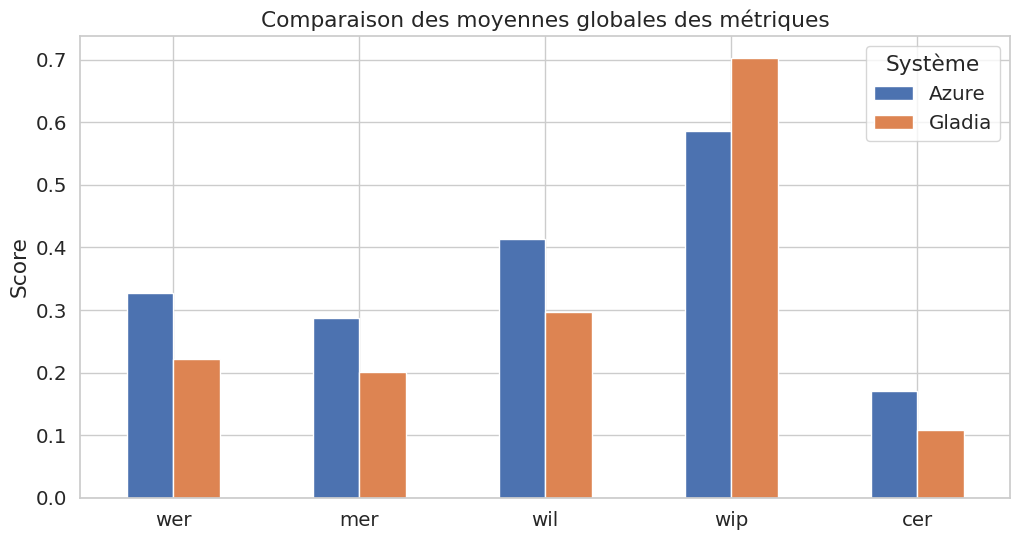

In [ ]:
metrics = ["wer", "mer", "wil", "wip", "cer"]

azure_means  = azure_eval_df[metrics].mean()
gladia_means = gladia_eval_df[metrics].mean()

compare_df = pd.DataFrame({
    "Azure": azure_means,
    "Gladia": gladia_means
})

compare_df.plot(kind="bar", figsize=(12,6))
plt.title("Comparaison des moyennes globales des métriques")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Système")
plt.show()


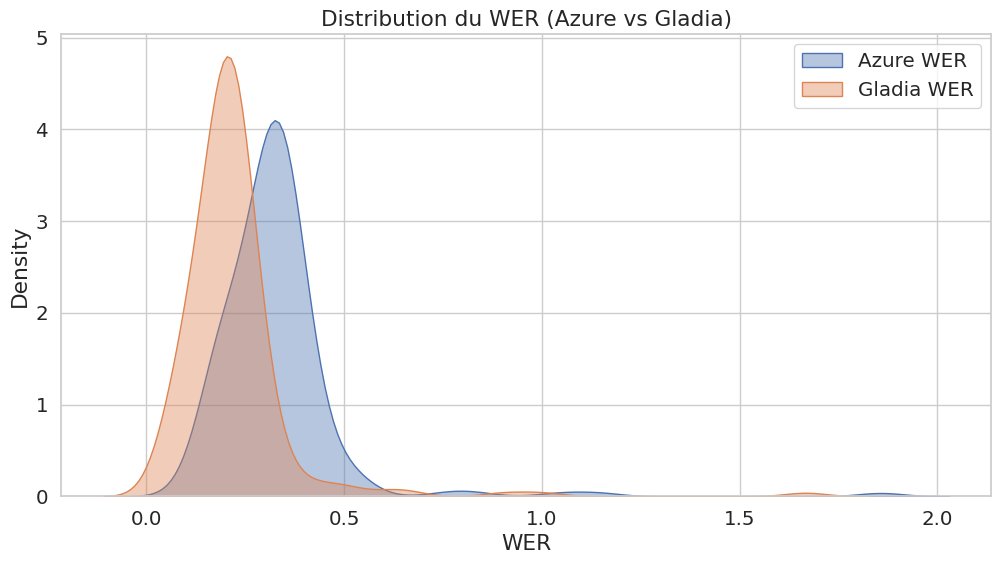

In [ ]:
plt.figure(figsize=(12,6))
sns.kdeplot(azure_eval_df["wer"], fill=True, label="Azure WER", alpha=0.4)
sns.kdeplot(gladia_eval_df["wer"], fill=True, label="Gladia WER", alpha=0.4)
plt.title("Distribution du WER (Azure vs Gladia)")
plt.xlabel("WER")
plt.legend()
plt.show()


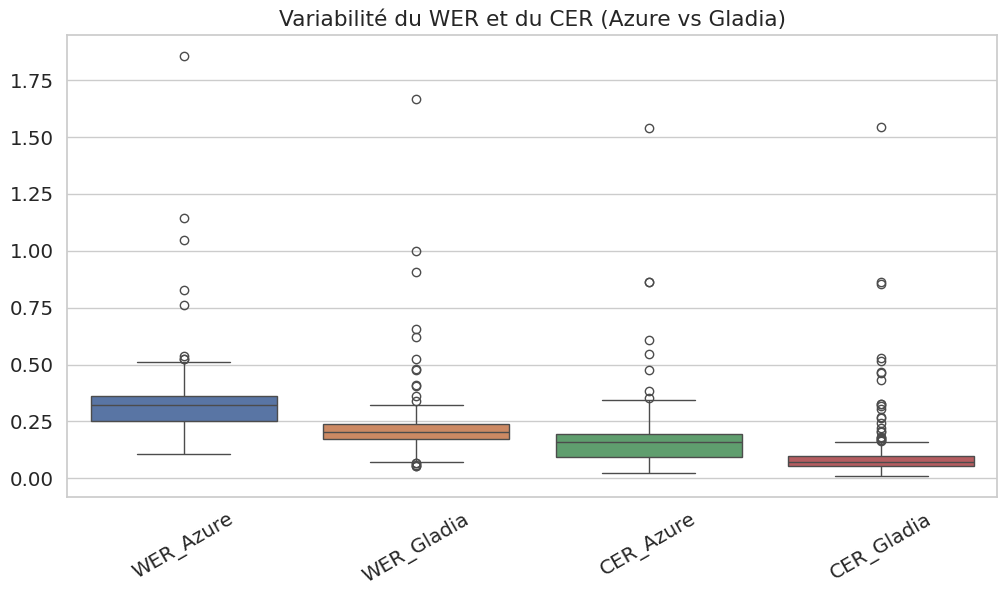

In [ ]:
wer_cer_df = pd.DataFrame({
    "WER_Azure": azure_eval_df["wer"],
    "WER_Gladia": gladia_eval_df["wer"],
    "CER_Azure": azure_eval_df["cer"],
    "CER_Gladia": gladia_eval_df["cer"],
})

plt.figure(figsize=(12,6))
sns.boxplot(data=wer_cer_df)
plt.title("Variabilité du WER et du CER (Azure vs Gladia)")
plt.xticks(rotation=30)
plt.show()


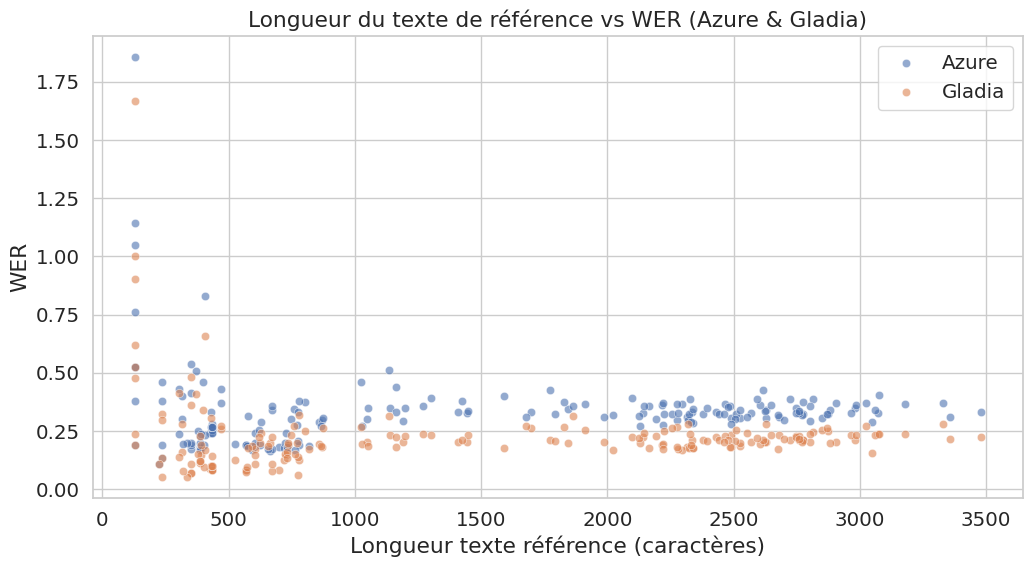

In [ ]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    x=azure_eval_df["ref_len_chars"],
    y=azure_eval_df["wer"],
    label="Azure",
    alpha=0.6
)
sns.scatterplot(
    x=gladia_eval_df["ref_len_chars"],
    y=gladia_eval_df["wer"],
    label="Gladia",
    alpha=0.6
)

plt.title("Longueur du texte de référence vs WER (Azure & Gladia)")
plt.xlabel("Longueur texte référence (caractères)")
plt.ylabel("WER")
plt.legend()
plt.show()

/tmp/ipykernel_3775735/2683177692.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="audio_id", x="wer", data=worst_azure, ax=ax[0], palette="Reds_r")
/tmp/ipykernel_3775735/2683177692.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="audio_id", x="wer", data=worst_gladia, ax=ax[1], palette="Blues_r")


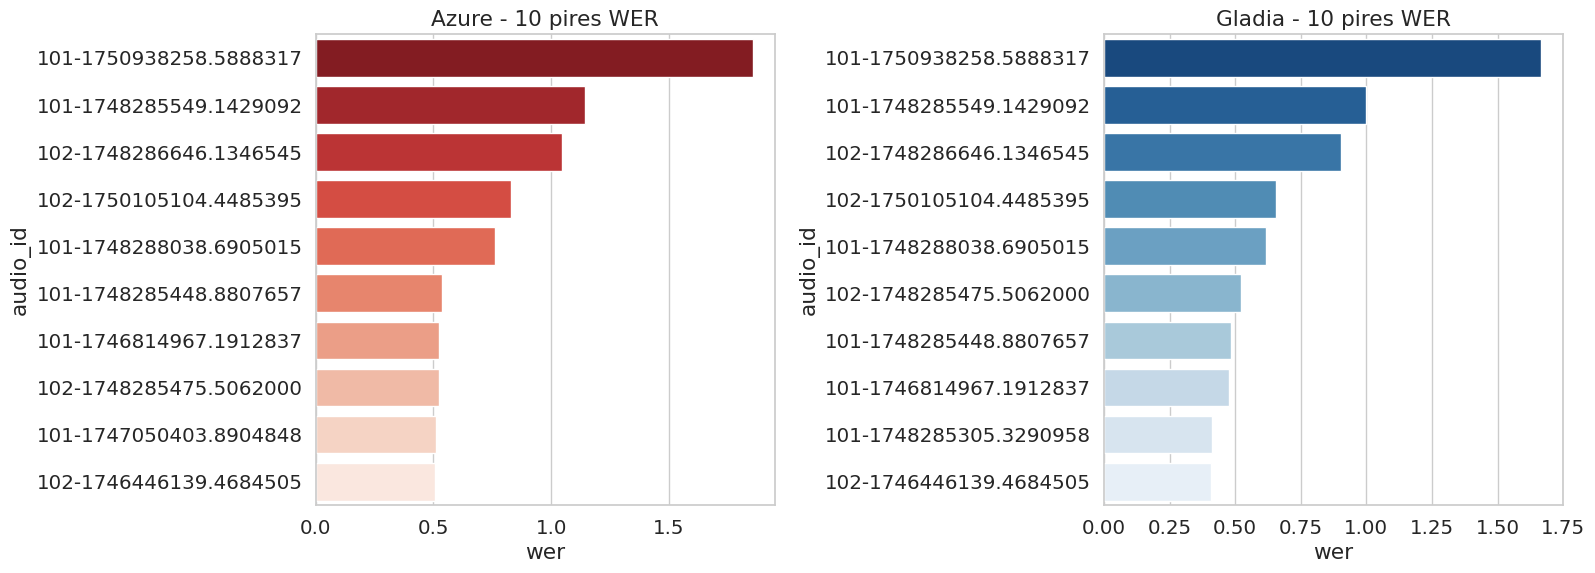

In [ ]:
worst_azure = azure_eval_df.nlargest(10, "wer")
worst_gladia = gladia_eval_df.nlargest(10, "wer")

fig, ax = plt.subplots(1, 2, figsize=(16,6))

sns.barplot(y="audio_id", x="wer", data=worst_azure, ax=ax[0], palette="Reds_r")
ax[0].set_title("Azure - 10 pires WER")

sns.barplot(y="audio_id", x="wer", data=worst_gladia, ax=ax[1], palette="Blues_r")
ax[1].set_title("Gladia - 10 pires WER")

plt.tight_layout()
plt.show()

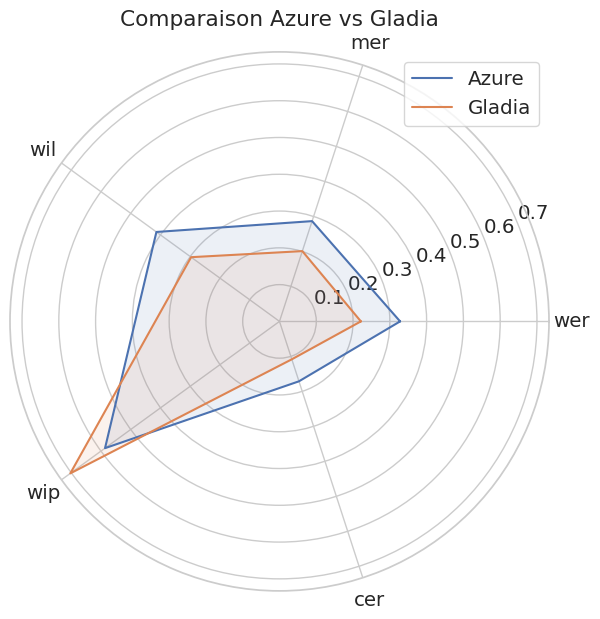

In [ ]:
from math import pi

metrics = ["wer", "mer", "wil", "wip", "cer"]

azure_vals  = azure_eval_df[metrics].mean().tolist()
gladia_vals = gladia_eval_df[metrics].mean().tolist()

# Close the circle
azure_vals += azure_vals[:1]
gladia_vals += gladia_vals[:1]
angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

plt.xticks(angles[:-1], metrics)

ax.plot(angles, azure_vals, label="Azure")
ax.fill(angles, azure_vals, alpha=0.1)

ax.plot(angles, gladia_vals, label="Gladia")
ax.fill(angles, gladia_vals, alpha=0.1)

plt.title("Comparaison Azure vs Gladia")
plt.legend(loc="upper right")
plt.show()